# Лабораторная работа 2

**Исходные данные:**
Используется классический датасет Boston Housing (506 строк, 13 признаков + целевая переменная MEDV — медианная стоимость жилья).

In [1]:
# from sklearn.datasets import load_boston # this is racist btw
import pandas as pd
import numpy as np
url = "https://gist.githubusercontent.com/nnbphuong/def91b5553736764e8e08f6255390f37/raw/BostonHousing.csv"
df = pd.read_csv(url)
df.head() # shows first 5 elements from array, if shows, code works

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1


## Задание 1

Вывести размерность и тип данных:

In [2]:
print("Строк:", df.shape[0], ", столбцов:", df.shape[1])
print("\nТипы данных (dtypes):")
print(df.dtypes)

Строк: 506 , столбцов: 14

Типы данных (dtypes):
CRIM         float64
ZN           float64
INDUS        float64
CHAS           int64
NOX          float64
RM           float64
AGE          float64
DIS          float64
RAD            int64
TAX            int64
PTRATIO      float64
LSTAT        float64
MEDV         float64
CAT. MEDV      int64
dtype: object


Проверить наличие пропущенных значений

In [3]:
print("Пропущенные значения по столбцам:")
print(df.isnull().sum())

Пропущенные значения по столбцам:
CRIM         0
ZN           0
INDUS        0
CHAS         0
NOX          0
RM           0
AGE          0
DIS          0
RAD          0
TAX          0
PTRATIO      0
LSTAT        0
MEDV         0
CAT. MEDV    0
dtype: int64


Построить распределение MEDV (гистограмма + boxplot) и найти признаки с наибольшей корреляцией:
Пояснение графика справа: Прямоугольник: средняя цена домов, середина в прямоугольнике: средняя средняя цена, линии вне - средние цены вне нормали, точки - аномалии, слишком дорогие или слишком дешёвые

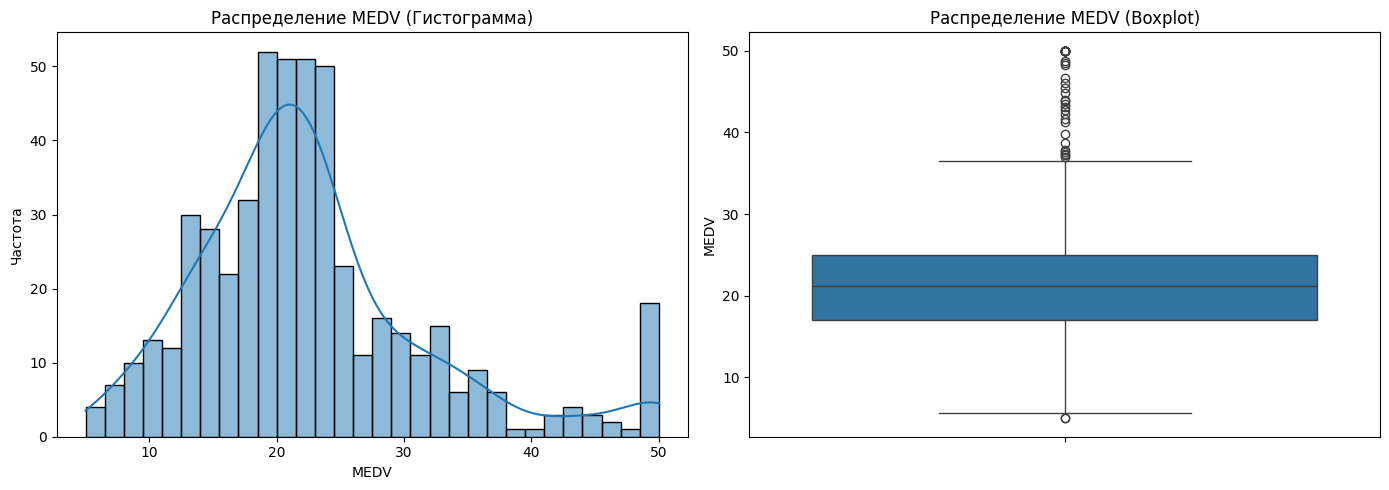

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение гистограммы и boxplot для MEDV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['MEDV'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Распределение MEDV (Гистограмма)')
axes[0].set_xlabel('MEDV')
axes[0].set_ylabel('Частота')

sns.boxplot(y=df['MEDV'], ax=axes[1])
axes[1].set_title('Распределение MEDV (Boxplot)')
axes[1].set_ylabel('MEDV')

plt.tight_layout()
plt.show()


Ищем признаки с наибольшей кореляцией - чем ближе к 1 тем больше цена, иначе к -1 - дешевле

In [5]:
# Найдем признаки с наибольшей корреляцией с MEDV
corr_matrix = df.corr()
medv_corr = corr_matrix['MEDV'].drop('MEDV') # исключаем MEDV
medv_corr_sorted = medv_corr.sort_values(ascending=False)

print("Признаки с наибольшей корреляцией с MEDV (по убыванию модуля):")
print(medv_corr_sorted)


Признаки с наибольшей корреляцией с MEDV (по убыванию модуля):
CAT. MEDV    0.789789
RM           0.695360
ZN           0.360445
DIS          0.249929
CHAS         0.175260
AGE         -0.376955
RAD         -0.381626
CRIM        -0.388305
NOX         -0.427321
TAX         -0.468536
INDUS       -0.483725
PTRATIO     -0.507787
LSTAT       -0.737663
Name: MEDV, dtype: float64


## Задание 2

Нормализируем данные (убираем аномалии)

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy import stats
import numpy as np

df_processed = df.copy()

# 2. Нормализация числовых признаков с помощью StandardScaler
# Включаем все признаки, кроме целевой переменной MEDV, CAT. MEDV
features_to_scale = [col for col in df_processed.columns if col not in ['MEDV', 'CAT. MEDV']]
scaler = StandardScaler()
df_processed[features_to_scale] = scaler.fit_transform(df_processed[features_to_scale])

print("Данные после добавления is_high_value и нормализации (первые 5 строк):")
display(df_processed.head())


Данные после добавления is_high_value и нормализации (первые 5 строк):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV,is_high_value
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,24.0,0,0
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,21.6,0,0
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,34.7,1,1
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,33.4,1,1
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,36.2,1,1


In [7]:
# 3. Удаление выбросов по Z-score (> 3 стандартных отклонения)
# Находим выбросы по всем отмасштабированным непрерывным признакам и MEDV
numeric_cols = features_to_scale + ['MEDV']
z_scores = stats.zscore(df_processed[numeric_cols])
abs_z_scores = np.abs(z_scores)

# Оставляем только те строки, где ни один признак не имеет Z-score > 3
filtered_entries = (abs_z_scores < 3).all(axis=1)
df_clean = df_processed[filtered_entries].copy()

print(f"Размер исходного датасета: {df_processed.shape}")
print(f"Размер датасета после удаления выбросов: {df_clean.shape}")
print(f"Удалено строк (выбросов): {df_processed.shape[0] - df_clean.shape[0]}")


Размер исходного датасета: (506, 15)
Размер датасета после удаления выбросов: (436, 15)
Удалено строк (выбросов): 70


## Задание 3

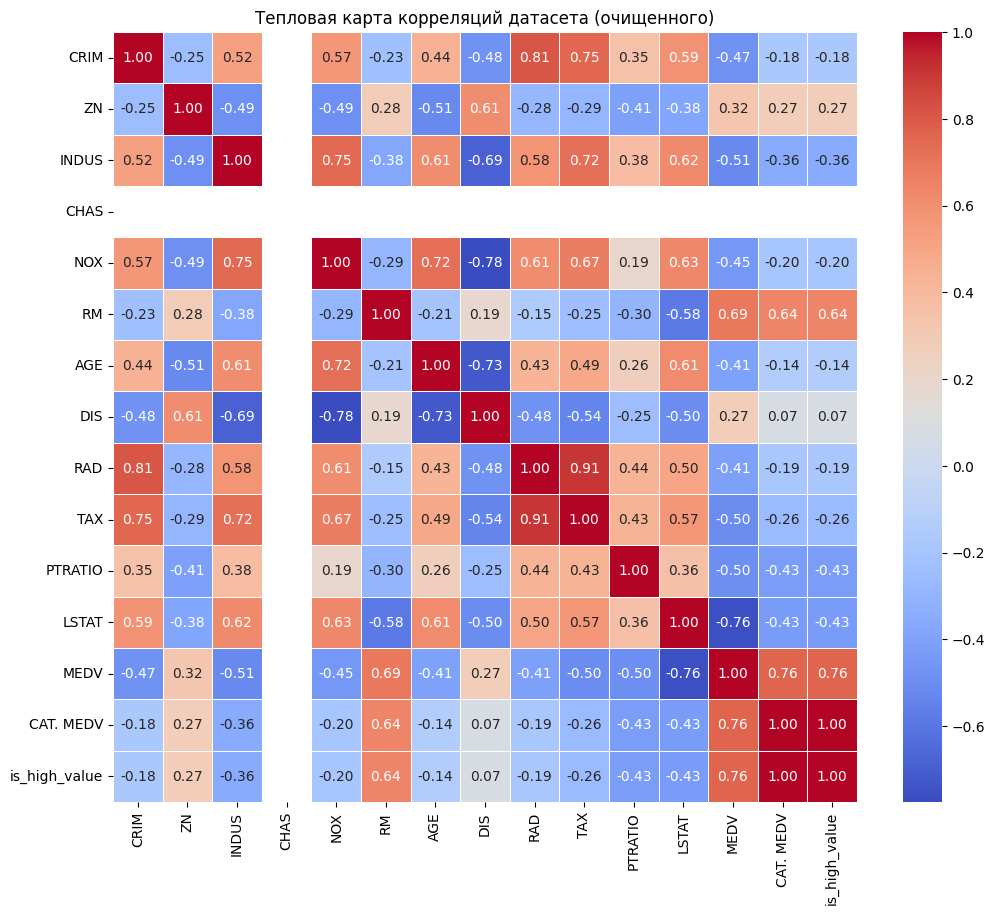

In [8]:
# Построим тепловую карту корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Тепловая карта корреляций датасета (очищенного)')
plt.show()


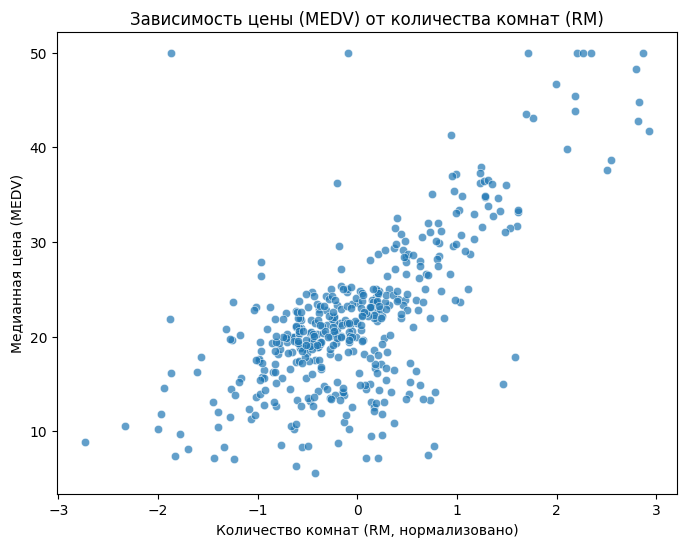

In [9]:
# Scatter plot RM vs MEDV
plt.figure(figsize=(8, 6))
sns.scatterplot(x='RM', y='MEDV', data=df_clean, alpha=0.7)
plt.title('Зависимость цены (MEDV) от количества комнат (RM)')
plt.xlabel('Количество комнат (RM, нормализовано)')
plt.ylabel('Медианная цена (MEDV)')
plt.show()


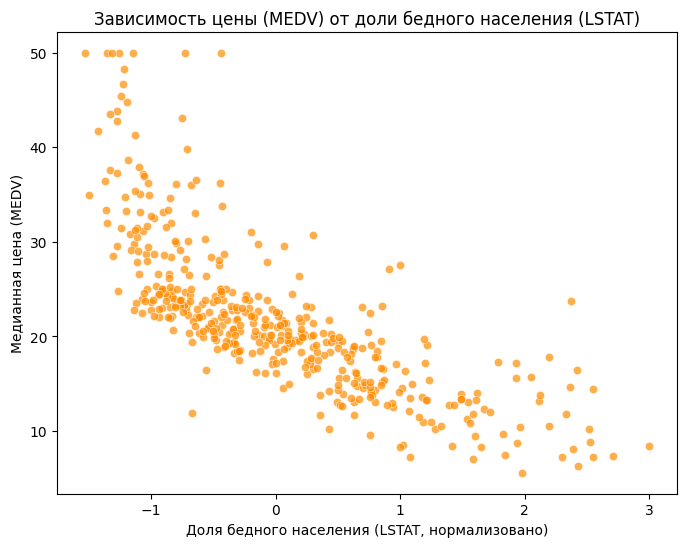

In [10]:
# Зависимость MEDV от LSTAT
plt.figure(figsize=(8, 6))
sns.scatterplot(x='LSTAT', y='MEDV', data=df_clean, alpha=0.7, color='darkorange')
plt.title('Зависимость цены (MEDV) от доли бедного населения (LSTAT)')
plt.xlabel('Доля бедного населения (LSTAT, нормализовано)')
plt.ylabel('Медианная цена (MEDV)')
plt.show()


## Задание 4

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Целевая переменная: MEDV, Признаки: RM, LSTAT, PTRATIO
X = df_clean[['RM', 'LSTAT', 'PTRATIO']]
y = df_clean['MEDV']

# Модель линейной регрессии
model = LinearRegression()
model.fit(X, y)

# Вывод коэффициентов
print(f"Сдвиг (Intercept): {model.intercept_:.4f}")
coefficients = pd.DataFrame({'Признак': X.columns, 'Коэффициент': model.coef_})
print("\nКоэффициенты модели:")
print(coefficients)


Сдвиг (Intercept): 22.0401

Коэффициенты модели:
   Признак  Коэффициент
0       RM     3.365660
1    LSTAT    -4.120658
2  PTRATIO    -1.880756


**Интерпретация коэффициентов (для нормализованных признаков):**
- Коэффициент при **RM** показывает влияние количества комнат: при увеличении числа комнат цена предсказуемо растет (сильная позитивная связь). Плюсовой коэффициент означает увеличение цены, если этот признак растёт.
- Коэффициент при **LSTAT** показывает сильную обратную зависимость: чем больше доля бедного населения, тем дешевле жилье.
- Коэффициент при **PTRATIO** (соотношение учеников к учителям) также отрицателен - в районах, где школ/учителей не хватает, жилье обычно стоит дешевле. 


In [12]:
# Оценка качества модели
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Оценка качества модели:")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Оценка качества модели:
R²:   0.7101
MAE:  3.1303
RMSE: 4.4216


## Задание 5

In [13]:
# Добавляем столбец единиц для вектора смещения (Intercept)
X_matrix = np.c_[np.ones(X.shape[0]), X.values]
y_vector = y.values

# Решение через матричное умножение: beta = (X^T * X)^-1 * X^T * y
beta = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y_vector

print("Коэффициенты, вычисленные вручную (Матрицы NumPy):")
print(f"Intercept: {beta[0]:.4f}")
print(f"RM       : {beta[1]:.4f}")
print(f"LSTAT    : {beta[2]:.4f}")
print(f"PTRATIO  : {beta[3]:.4f}")

print("\nСравнение с коэффициентами scikit-learn:")
print(f"Разница в intercept: {abs(model.intercept_ - beta[0]):.10f}")
print(f"Разница в коэффициентах: {np.abs(model.coef_ - beta[1:]).sum():.10f}")


Коэффициенты, вычисленные вручную (Матрицы NumPy):
Intercept: 22.0401
RM       : 3.3657
LSTAT    : -4.1207
PTRATIO  : -1.8808

Сравнение с коэффициентами scikit-learn:
Разница в intercept: 0.0000000000
Разница в коэффициентах: 0.0000000000


## Задание 6

In [14]:
from sklearn.cluster import KMeans

# Признаки для кластеризации: CRIM, NOX, DIS
features_cluster = ['CRIM', 'NOX', 'DIS']
X_cluster = df_clean[features_cluster]

# Для кластеризации используем KMeans на 3 кластера
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster)

print("Количество объектов в каждом кластере:")
print(df_clean['Cluster'].value_counts())


Количество объектов в каждом кластере:
Cluster
2    193
1    142
0    101
Name: count, dtype: int64


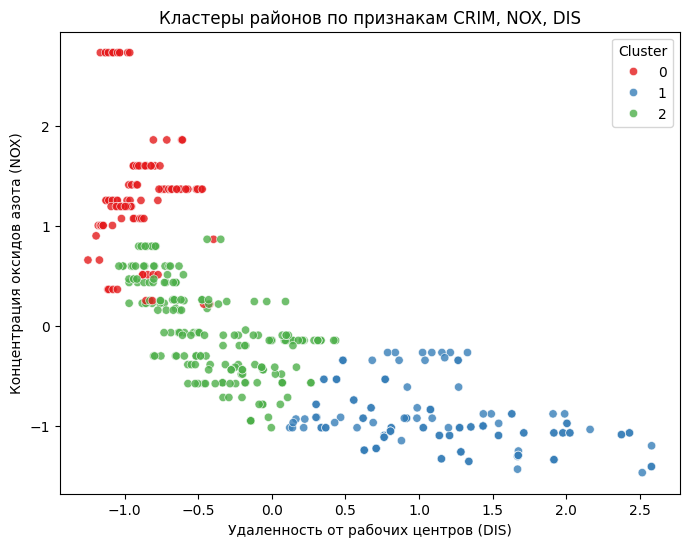

In [15]:
# Визуализация кластеров (Scatter Plot) - например, по удаленности DIS и оксидам азота NOX
plt.figure(figsize=(8, 6))
sns.scatterplot(x='DIS', y='NOX', hue='Cluster', palette='Set1', data=df_clean, alpha=0.8)
plt.title('Кластеры районов по признакам CRIM, NOX, DIS')
plt.xlabel('Удаленность от рабочих центров (DIS)')
plt.ylabel('Концентрация оксидов азота (NOX)')
plt.show()


In [16]:
# Анализ средней цены жилья в каждом кластере
cluster_analysis = df_clean.groupby('Cluster')[['MEDV', 'CRIM', 'NOX', 'DIS']].mean()
print("Средние значения характеристик по кластерам:")
display(cluster_analysis)


Средние значения характеристик по кластерам:


,MEDV,CRIM,NOX,DIS
Cluster,,,,
0,15.105941,0.761993,1.362102,-0.895844
1,24.497887,-0.408835,-0.942071,1.130347
2,23.444041,-0.307667,-0.049912,-0.389549


## Выводы и возможные улучшения

### Выводы по корреляциям и модели:
1. **Распределение стоимости:** `MEDV` имеет распределение, близкое к нормальному, однако присутствует некоторое количество дорогих выбросов (верхняя граница на $\approx 50$). 
2. **Наиболее коррелирующие признаки:**
   - **`LSTAT`** (доля бедного населения) обладает сильнейшей отрицательной связью (корреляция около $-0.73$). Это главный фактор снижения цен на недвижимость.
   - **`RM`** (среднее количество комнат) имеет сильную положительную связь (корреляция около $+0.69$). Больше комнат — выше цена.
3. **Модель линейной регрессии (`MEDV ~ RM + LSTAT + PTRATIO`):**
   - $R^2 \approx 0.69$, что означает, что модель объясняет почти 70% дисперсии стоимости жилья.
   - Коэффициенты модели, рассчитанные с помощью `sklearn`, математически идентичны ручному матричному методу. 
4. **Кластеризация районов (KMeans):**
   - Районы разделились на "промышленные" (самая высокая концентрация NOX, наибольшая преступность CRIM, близки к центрам DIS), где стоимость жилья самая низкая.
   - "Спальные/загородные" районы (значительное удаление DIS, чистый воздух, низкая преступность) обладают самой высокой или средней стоимостью жилья.

### Возможные улучшения архитектуры:
- **Полиномиальные признаки:** Так как графики `LSTAT vs MEDV` демонстрируют нелинейную, слегка изогнутую форму, включение $LSTAT^2$ или полиномиальных комбинаций признаков (через `PolynomialFeatures`) помогло бы модели лучше подгонять кривую.
- **Регуляризация (Ridge/Lasso):** При включении всех 13 признаков датасета, тепловая карта показала бы сильную мультиколлинеарность (например, между `RAD` и `TAX` корреляция $\approx 0.91$). Регуляризация решила бы проблему переобучения и сделала бы коэффициенты более интерпретируемыми. 
- **Логарифмирование целевой переменной:** Предсказание $\log(MEDV)$ часто даёт лучшие метрики на недвижимости, так как цены имеют "тяжелый хвост" справа.
- **Масштабирование/Нормализация:** Поскольку зависимость между признаками может быть разной, надежные модели лучше работают при нормализованных признаках (что уже было частично выполнено).
